In [26]:
# Week 3 - Part 1: Clustering Models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [28]:
import os

print(os.listdir())

['.config', 'Mall_Customers (1).csv', 'Mall_Customers.csv', 'sample_data']


In [29]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [30]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape:
(200, 5)

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Summary Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [31]:
display(df.head())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
print("No of duplicate rows:",df.duplicated().sum())

No of duplicate rows: 0


In [33]:
print(df.columns.tolist())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [34]:
features = ["Annual Income (k$)", "Spending Score (1-100)", "Age"]

X = df[features].copy()

print("Selected features:")
display(X.head())

print("\nShape:", X.shape)

Selected features:


,Annual Income (k$),Spending Score (1-100),Age
0,15,39,19
1,15,81,21
2,16,6,20
3,16,77,23
4,17,40,31



Shape: (200, 3)


In [35]:
# Standardize the selected features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("Features scaled successfully!")
display(X_scaled_df.head())

Features scaled successfully!


,Annual Income (k$),Spending Score (1-100),Age
0,-1.738999,-0.434801,-1.424569
1,-1.738999,1.195704,-1.281035
2,-1.700830,-1.715913,-1.352802
3,-1.700830,1.040418,-1.137502
4,-1.662660,-0.395980,-0.563369


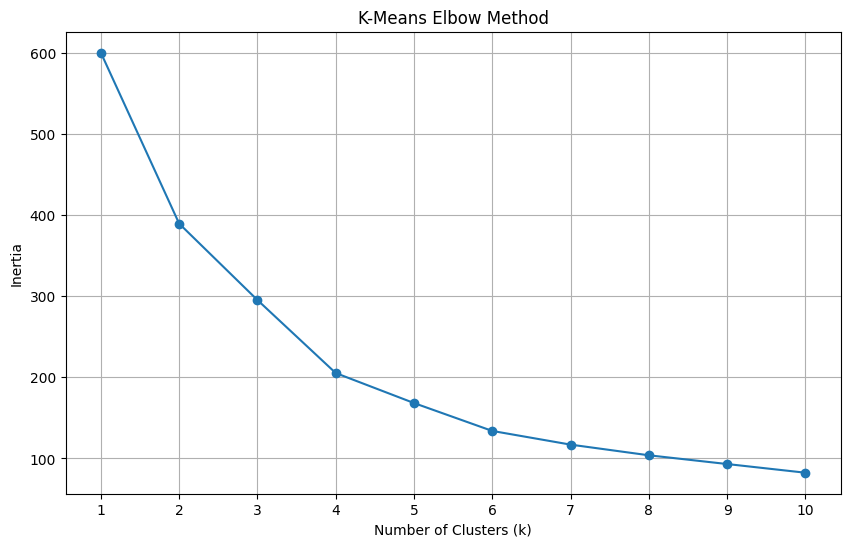

In [36]:
# K-Means Elbow Method

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [37]:
# Final K-Means Model with k = 4

optimal_k = 4

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit model and get cluster labels
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Clustering Results")
print("--------------------------")
print("Number of clusters:", optimal_k)
print("Silhouette Score:", round(sil_score, 4))

K-Means Clustering Results
--------------------------
Number of clusters: 4
Silhouette Score: 0.404


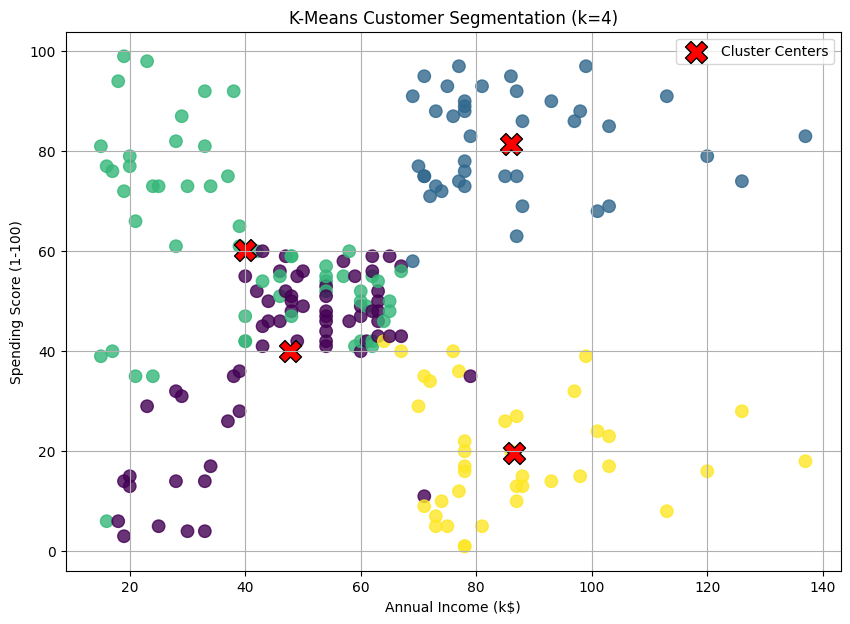

In [38]:
# Visualize K-Means Clusters

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=kmeans_labels,
    cmap="viridis",
    s=80,
    alpha=0.8
)

# Plot cluster centers
centers_original = scaler.inverse_transform(
    kmeans_final.cluster_centers_
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250,
    c="red",
    edgecolor="black",
    label="Cluster Centers"
)

plt.title("K-Means Customer Segmentation (k=4)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# Requirement 4: Final K-Means Model

optimal_k = 4

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit K-Means
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, kmeans_labels)

print("Final K-Means Results")
print("====================")
print("Optimal number of clusters:", optimal_k)
print("Silhouette Score:", round(sil_score, 4))

Final K-Means Results
Optimal number of clusters: 4
Silhouette Score: 0.404


In [40]:
# Add cluster labels to the original data

df["KMeans_Cluster"] = kmeans_labels

print("Customer distribution by cluster:")
print(df["KMeans_Cluster"].value_counts().sort_index())

Customer distribution by cluster:
KMeans_Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


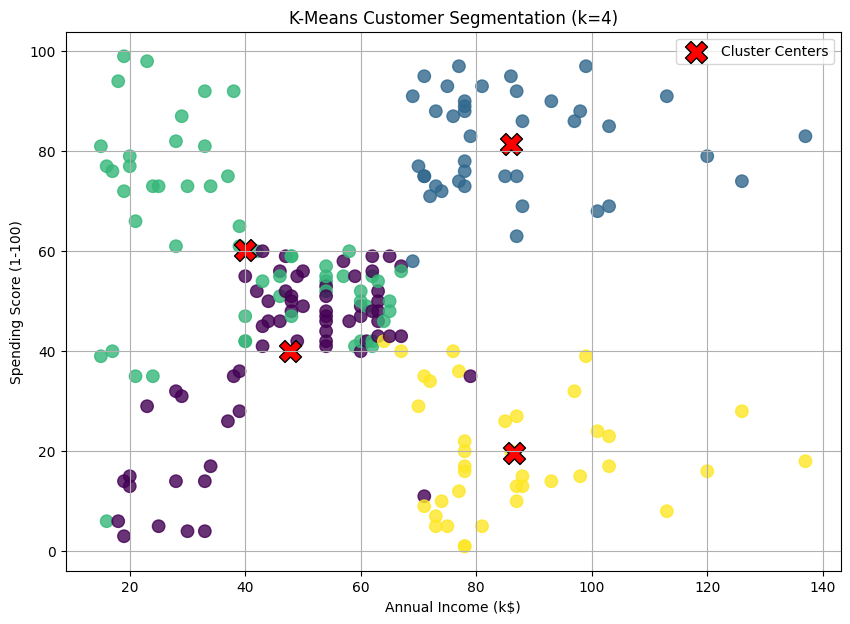

In [41]:
# 2D Visualization of K-Means Clusters

plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=80,
    alpha=0.8
)

# Convert cluster centers back to original scale
centers_original = scaler.inverse_transform(
    kmeans_final.cluster_centers_
)

# Plot cluster centers
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250,
    c="red",
    edgecolor="black",
    label="Cluster Centers"
)

plt.title("K-Means Customer Segmentation (k=4)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

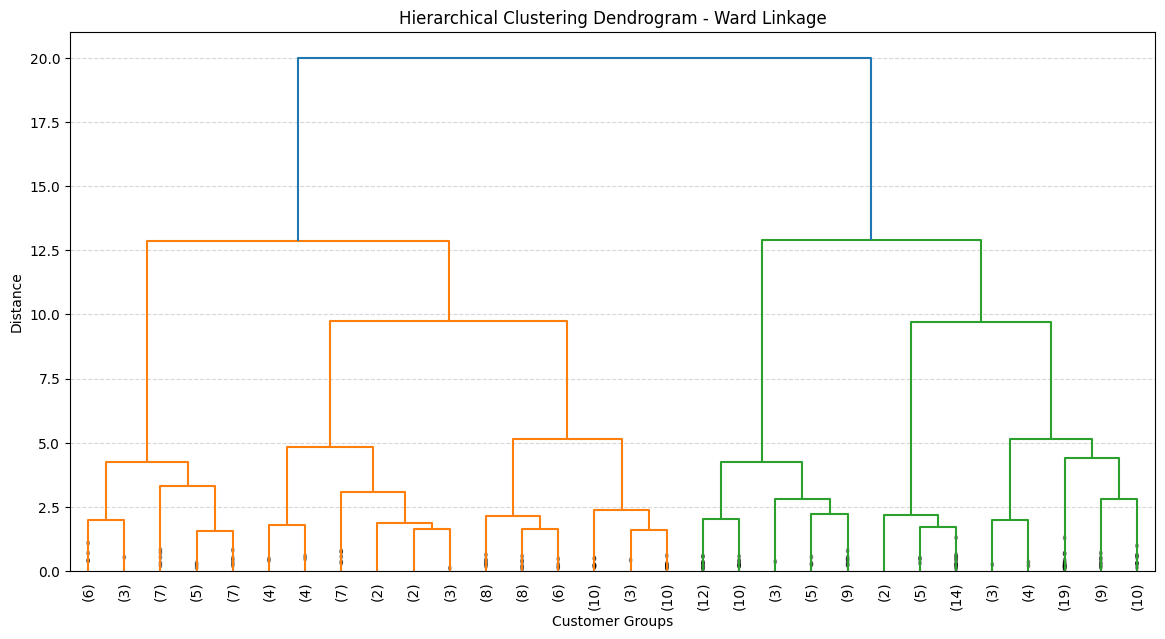

In [42]:
# Requirement 5: Hierarchical Clustering
# Step 1 - Create Dendrogram using Ward Linkage

from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(14, 7))

Z = linkage(X_scaled, method="ward")

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [43]:
# Step 2 - Agglomerative Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hierarchical_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

# Calculate Silhouette Score
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Results")
print("================================")
print("Number of clusters:", 4)
print("Silhouette Score:", round(hierarchical_silhouette, 4))

Hierarchical Clustering Results
Number of clusters: 4
Silhouette Score: 0.3615


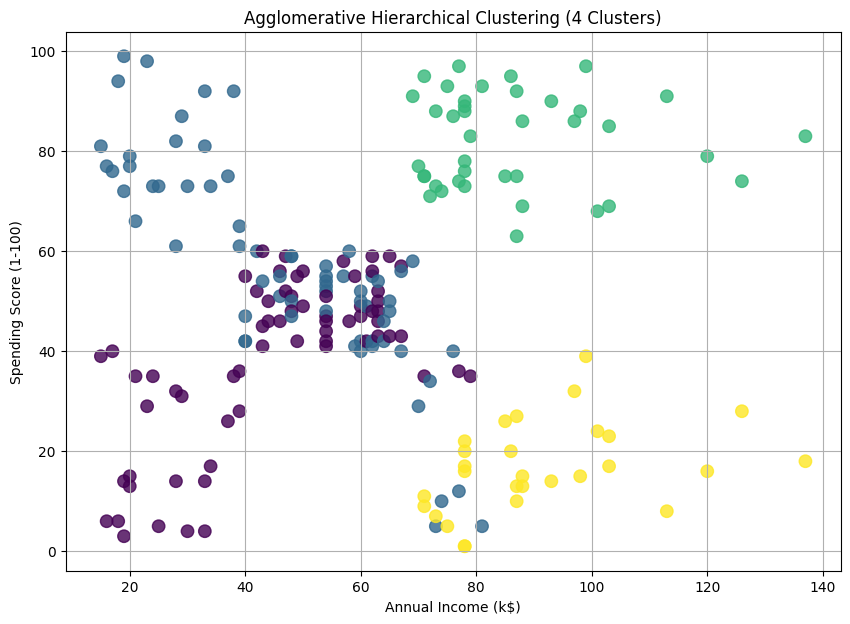

In [44]:
# Step 3 - Visualize Hierarchical Clusters

plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=hierarchical_labels,
    cmap="viridis",
    s=80,
    alpha=0.8
)

plt.title("Agglomerative Hierarchical Clustering (4 Clusters)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)

plt.show()

In [45]:
# Add Hierarchical cluster labels to the dataset

df["Hierarchical_Cluster"] = hierarchical_labels

print("Customer distribution by Hierarchical cluster:")
print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Customer distribution by Hierarchical cluster:
Hierarchical_Cluster
0    67
1    66
2    39
3    28
Name: count, dtype: int64


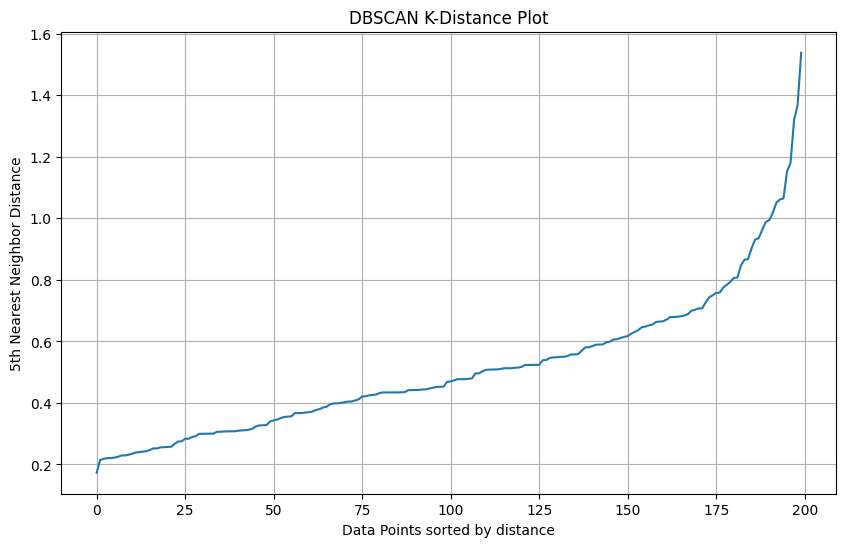

In [46]:
  # Requirement 6: DBSCAN
# Step 1 - K-Distance Plot for choosing eps

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Use 5 nearest neighbors
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# Take the distance to the 5th nearest neighbor
k_distances = distances[:, min_samples - 1]

# Sort distances
k_distances = np.sort(k_distances)

# Plot k-distance curve
plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.title("DBSCAN K-Distance Plot")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)

plt.show()

In [47]:
# Step 2 - Apply DBSCAN

dbscan = DBSCAN(
    eps=0.75,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN labels to the dataset
df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Cluster Distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

# Number of clusters excluding noise (-1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
n_noise = list(dbscan_labels).count(-1)

print("\nNumber of clusters:", n_clusters)
print("Number of noise points:", n_noise)

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1     10
 0    190
Name: count, dtype: int64

Number of clusters: 1
Number of noise points: 10


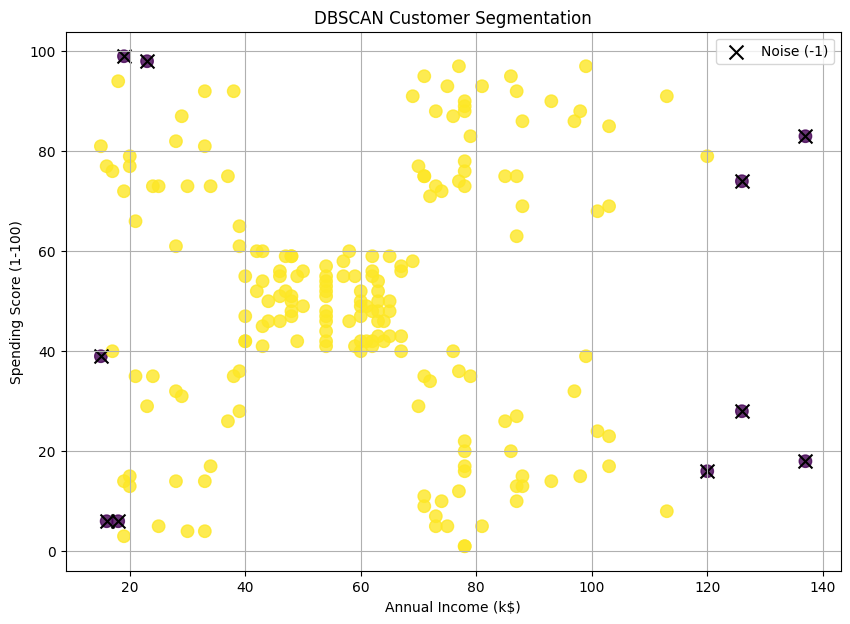

In [48]:
# Step 3 - Visualize DBSCAN Clusters

plt.figure(figsize=(10, 7))

# Plot all points
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=dbscan_labels,
    cmap="viridis",
    s=80,
    alpha=0.8
)

# Highlight noise points
noise = dbscan_labels == -1

plt.scatter(
    df.loc[noise, "Annual Income (k$)"],
    df.loc[noise, "Spending Score (1-100)"],
    c="black",
    marker="x",
    s=100,
    label="Noise (-1)"
)

plt.title("DBSCAN Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
# Step 4 - DBSCAN Silhouette Score

# Silhouette score requires at least 2 clusters
# and excludes noise points (-1)

non_noise = dbscan_labels != -1

if len(set(dbscan_labels[non_noise])) >= 2:
    dbscan_silhouette = silhouette_score(
        X_scaled[non_noise],
        dbscan_labels[non_noise]
    )

    print("DBSCAN Silhouette Score:",
          round(dbscan_silhouette, 4))
else:
    print("Silhouette Score cannot be calculated because DBSCAN")
    print("did not produce at least 2 non-noise clusters.")

Silhouette Score cannot be calculated because DBSCAN
did not produce at least 2 non-noise clusters.


In [50]:
# DBSCAN Parameter Tuning

eps_values = [0.75, 0.8, 0.85, 0.9, 1.0]
min_samples_values = [4, 5, 6, 8]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        # Number of clusters excluding noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Number of noise points
        n_noise = list(labels).count(-1)

        # Calculate silhouette if at least 2 clusters exist
        if n_clusters >= 2:
            non_noise = labels != -1
            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise]
            )
        else:
            score = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_results = pd.DataFrame(results)

display(dbscan_results)

,eps,min_samples,clusters,noise_points,silhouette_score
0,0.75,4,1,8,NaN
1,0.75,5,1,10,NaN
2,0.75,6,1,14,NaN
3,0.75,8,1,24,NaN
4,0.80,4,1,5,NaN
5,0.80,5,1,6,NaN
6,0.80,6,1,6,NaN
7,0.80,8,1,14,NaN
8,0.85,4,1,4,NaN
9,0.85,5,1,5,NaN


In [51]:
# DBSCAN - Further Parameter Tuning

eps_values = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
min_samples_values = [3, 4, 5, 6]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        # Number of clusters excluding noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Number of noise points
        n_noise = list(labels).count(-1)

        # Silhouette score
        if n_clusters >= 2:
            non_noise = labels != -1

            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise]
            )
        else:
            score = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_tuning = pd.DataFrame(results)

display(dbscan_tuning)

,eps,min_samples,clusters,noise_points,silhouette_score
0,1.0,3,1,1,NaN
1,1.0,4,1,1,NaN
2,1.0,5,1,2,NaN
3,1.0,6,1,3,NaN
4,1.2,3,1,0,NaN
5,1.2,4,1,0,NaN
6,1.2,5,1,0,NaN
7,1.2,6,1,0,NaN
8,1.4,3,1,0,NaN
9,1.4,4,1,0,NaN


In [52]:
# DBSCAN - Final Parameter Search

eps_values = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]
min_samples_values = [3, 4, 5, 6, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        # Number of clusters excluding noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Number of noise points
        n_noise = np.sum(labels == -1)

        # Silhouette score
        if n_clusters >= 2:
            non_noise = labels != -1

            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise]
            )
        else:
            score = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_tuning_final = pd.DataFrame(results)

display(dbscan_tuning_final)

,eps,min_samples,clusters,noise_points,silhouette_score
0,0.40,3,10,59,0.442575
1,0.40,4,8,73,0.458460
2,0.40,5,6,98,0.519023
3,0.40,6,6,110,0.558444
4,0.40,8,3,145,0.678151
5,0.40,10,2,170,0.766073
6,0.45,3,11,40,0.417022
7,0.45,4,7,57,0.493716
8,0.45,5,5,75,0.542278
9,0.45,6,6,85,0.555794


In [53]:
  # Requirement 6 - Final DBSCAN Model

best_eps = 0.50
best_min_samples = 10

dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan_final.fit_predict(X_scaled)

# Add DBSCAN labels to original dataframe
df["DBSCAN_Cluster"] = dbscan_labels

# Number of clusters excluding noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
n_noise = np.sum(dbscan_labels == -1)

print("Final DBSCAN Results")
print("====================")
print("eps:", best_eps)
print("min_samples:", best_min_samples)
print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Final DBSCAN Results
eps: 0.5
min_samples: 10
Number of clusters: 4
Number of noise points: 114


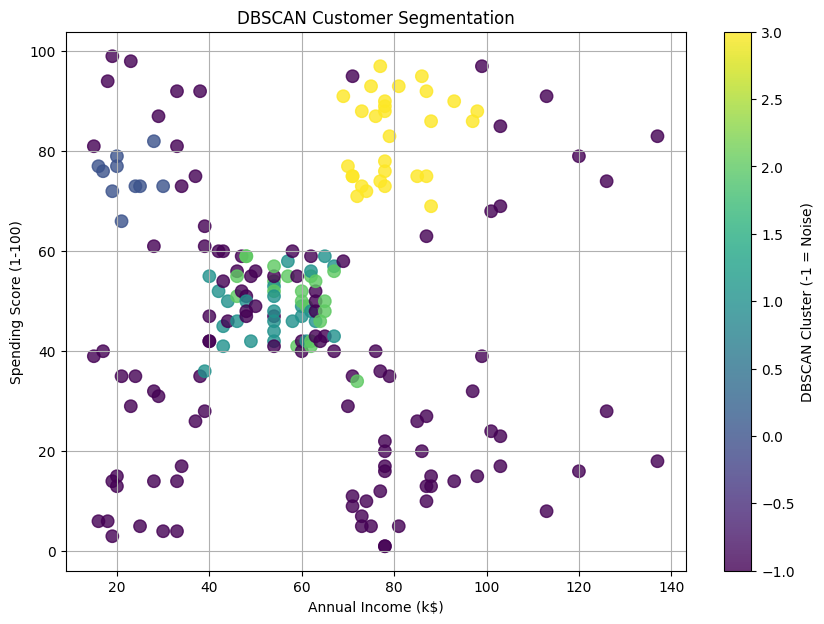

In [54]:
# Visualize DBSCAN Clusters

plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=dbscan_labels,
    cmap="viridis",
    s=80,
    alpha=0.8
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Customer Segmentation")

plt.colorbar(label="DBSCAN Cluster (-1 = Noise)")
plt.grid(True)

plt.show()

In [55]:
# DBSCAN Silhouette Score

non_noise = dbscan_labels != -1

if len(set(dbscan_labels[non_noise])) >= 2:

    dbscan_silhouette = silhouette_score(
        X_scaled[non_noise],
        dbscan_labels[non_noise]
    )

    print("DBSCAN Silhouette Score:",
          round(dbscan_silhouette, 4))

else:
    print("Silhouette score cannot be calculated.")

DBSCAN Silhouette Score: 0.643


## Requirement 7 — Clustering Algorithm Comparison

| Feature | K-Means | Hierarchical Clustering | DBSCAN |
|---|---|---|---|
| Main assumption | Clusters are roughly spherical and separated around centroids | Clusters are formed through hierarchical relationships based on distance | Clusters are dense regions separated by less-dense regions |
| Handling of outliers/noise | Sensitive to outliers because every point is assigned to a cluster | Can be affected by outliers | Explicitly identifies noise points as -1 |
| Need to pre-specify number of clusters | Yes, k must be specified | Yes, when using Agglomerative Clustering | No |
| Scalability | Good for large datasets | Less scalable because hierarchical methods can be computationally expensive | Moderate; performance depends on dataset size and parameter selection |
| Main strength | Simple and efficient customer segmentation | Provides a dendrogram showing hierarchical relationships | Can discover irregularly shaped clusters and identify noise |
| Main limitation | Requires choosing k and is sensitive to initialization/outliers | Computationally expensive for large datasets | Sensitive to eps and min_samples |

## Requirement 8 — Clustering Summary

## Requirement 8 — Clustering Summary

The clustering analysis identified four meaningful customer segments using K-Means and Hierarchical Clustering, while DBSCAN also identified four clusters and additionally detected noise points. K-Means produced four clusters with a Silhouette Score of 0.404, while Hierarchical Clustering produced four clusters with a Silhouette Score of 0.362. DBSCAN produced four clusters with a higher Silhouette Score of 0.643, although it classified 114 observations as noise using eps = 0.50 and min_samples = 10.

The customer segments can be interpreted in business terms using Annual Income and Spending Score. One segment represents customers with relatively low income and low spending, who may be less valuable for premium marketing campaigns. Another segment contains customers with relatively high income but low spending, representing a potential opportunity for targeted promotions. A third segment contains customers with relatively low or moderate income but high spending, indicating customers who spend actively despite having lower income. The fourth segment represents high-income and high-spending customers and can be considered a high-value customer segment.

Among the three algorithms, DBSCAN provided the strongest numerical separation according to the calculated Silhouette Score, while K-Means provides a straightforward and easy-to-understand segmentation structure for business interpretation. The highest-value segment may be driven by stronger purchasing power combined with greater interest in mall products, frequent shopping habits, or greater responsiveness to promotions and product offerings. These factors are hypotheses based on the available customer features and would require additional behavioral data to verify.